In [13]:
import pandas as pd
import requests
import time
import os
import torch
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from io import StringIO


**Load processed data to find IDs**

In [14]:
input_csv = '../data/processed/sequences_parsed.csv'
sequences_parsed = pd.read_csv(input_csv)

**Fetch Descriptions**

In [24]:
cache_file = '../data/processed/uniprot_rich_text_cache.csv'

os.makedirs(os.path.dirname(cache_file), exist_ok=True)

if os.path.exists(cache_file):
    print(f"Found existing cache! Loading from {cache_file}...")
    df_texts = pd.read_csv(cache_file)
else:
    print("Fetching rich textual data from UniProt...")
    
    annotated_ids = [str(pid) for pid in sequences_parsed['uniref_id'] if not str(pid).startswith('UPI')]
    print(f"Attempting to fetch data for {len(annotated_ids)} valid accessions...")
    
    def chunk_list(lst, n):
        for i in range(0, len(lst), n):
            yield lst[i:i + n]
            
    batches = list(chunk_list(annotated_ids, 200))
    all_dataframes = []
    
    for i, batch in enumerate(batches):
        print(f"Fetching batch {i+1}/{len(batches)}...")
        joined_ids = ",".join(batch)
        
        url = f"https://rest.uniprot.org/uniprotkb/accessions?accessions={joined_ids}&format=tsv&fields=accession,protein_name,protein_families,cc_function,go,gene_names,organism_name"

        try:
            response = requests.get(url)
            if response.status_code == 200:
                df_batch = pd.read_csv(StringIO(response.text), sep='\t')
                all_dataframes.append(df_batch)
        except Exception as e:
            print(f"Error on batch {i+1}: {e}")
            
        time.sleep(1)
        
    if all_dataframes:
        df_raw = pd.concat(all_dataframes, ignore_index=True)
        df_raw = df_raw.fillna('')
        
        df_raw['rich_text'] = (
            df_raw.get('Protein Names', '') + ". " +
            df_raw.get('Protein Families', '') + ". " +
            df_raw.get('Function [CC]', '') + ". " +
            df_raw.get('Gene Ontology (GO)', '') + ". " +
            df_raw.get('Gene Names') + ". " +
            df_raw.get('Organism', '')
        )
        
        df_texts = df_raw[['Entry', 'rich_text']].rename(columns={'Entry': 'uniref_id', 'rich_text': 'function_text'})
        
        df_texts.to_csv(cache_file, index=False)
        print(f"Success! Retrieved and saved highly detailed text for {len(df_texts)} proteins to {cache_file}.")
    else:
        print("Failed to fetch data.")

pd.set_option('display.max_colwidth', 200) 
display(df_texts.head())

Found existing cache! Loading from ../data/processed/uniprot_rich_text_cache.csv...


,uniref_id,function_text
0,P07550,". . FUNCTION: G protein-coupled receptor for catecholamines that couples to both G(s) and G(i) proteins, activating bifurcated signaling pathways (PubMed:2831218, PubMed:7915137). ADRB2 binds epin..."
1,A0A8D2HM49,. . FUNCTION: Beta-adrenergic receptors mediate the catecholamine-induced activation of adenylate cyclase through the action of G proteins. The beta-2-adrenergic receptor binds epinephrine with an...
2,A0A250YHJ2,. . FUNCTION: Beta-adrenergic receptors mediate the catecholamine-induced activation of adenylate cyclase through the action of G proteins. The beta-2-adrenergic receptor binds epinephrine with an...
3,A0A8C9AQU3,. . FUNCTION: Beta-adrenergic receptors mediate the catecholamine-induced activation of adenylate cyclase through the action of G proteins. The beta-2-adrenergic receptor binds epinephrine with an...
4,A0A8B7PU76,. . FUNCTION: Beta-adrenergic receptors mediate the catecholamine-induced activation of adenylate cyclase through the action of G proteins. The beta-2-adrenergic receptor binds epinephrine with an...


**Embedding with Sentence-BERT**

In [26]:
if torch.cuda.is_available():
    device = 'cuda'
    print("Using NVIDIA GPU (CUDA)")
else:
    device = 'cpu'
    print("No GPU detected. Falling back to CPU.")

print(f"Loading Sentence-BERT model on {device}...")
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

texts = df_texts['function_text'].tolist()

print("Embedding texts into vectors...")
embeddings = model.encode(texts, show_progress_bar=True)
print(f"Created embeddings with shape: {embeddings.shape}")

Using NVIDIA GPU (CUDA)
Loading Sentence-BERT model on cuda...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 342.57it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding texts into vectors...


Batches: 100%|██████████| 33/33 [00:06<00:00,  5.46it/s]

Created embeddings with shape: (1038, 384)


**Calculate Semantic Overlap & Cluster**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print("Calculating similarity and distance matrices...")

# 1. Calculate how similar every text is to every other text (Scores from 0 to 1)
# 1 means identical, 0 means completely different
similarity_matrix = cosine_similarity(embeddings)

# 2. Convert Similarity into Distance
# Clustering algorithms need "distance" (how far apart things are), not similarity.
# If similarity is 0.99, distance becomes 0.01 (very close!).
distance_matrix = 1 - similarity_matrix 

# 3. Clip to avoid negative values due to floating-point precision errors
distance_matrix = np.clip(distance_matrix, 0, None)

print(f"Distance matrix created with shape: {distance_matrix.shape}")
print("You are now ready to cluster!")

Calculating similarity and distance matrices...
✅ Distance matrix created with shape: (1038, 1038)
You are now ready to cluster!


Testing different cluster sizes...
k=2: Silhouette Score = 0.3309
k=3: Silhouette Score = 0.2951
k=4: Silhouette Score = 0.2943
k=5: Silhouette Score = 0.2811
k=6: Silhouette Score = 0.2644
k=7: Silhouette Score = 0.2452
k=8: Silhouette Score = 0.1946
k=9: Silhouette Score = 0.1940
k=10: Silhouette Score = 0.1892
k=11: Silhouette Score = 0.1830
k=12: Silhouette Score = 0.1665
k=13: Silhouette Score = 0.1629
k=14: Silhouette Score = 0.1978
k=15: Silhouette Score = 0.1884

🏆 The math says the BEST number of clusters is: 2


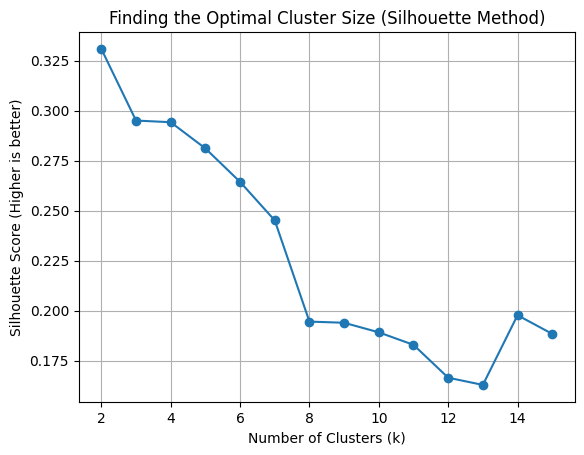

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# We want to test cluster sizes from 2 up to 15
possible_k_values = range(2, 16)
silhouette_scores = []

print("Testing different cluster sizes...")

for k in possible_k_values:
    # Try clustering with the current 'k'
    test_model = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    test_labels = test_model.fit_predict(distance_matrix)
    
    # Calculate how good this 'k' was
    score = silhouette_score(distance_matrix, test_labels, metric='precomputed')
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

# Find the K that gave the highest score
best_k = possible_k_values[np.argmax(silhouette_scores)]
print(f"\nThe math says the BEST number of clusters is: {best_k}")

# Optional: Plot the results so you can put it in your presentation!
plt.plot(possible_k_values, silhouette_scores, marker='o')
plt.title('Finding the Optimal Cluster Size (Silhouette Method)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score (Higher is better)')
plt.grid(True)
plt.show()

# Now run your final clustering with the mathematically proven best K
final_clustering_model = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage='average')
df_texts['text_cluster'] = final_clustering_model.fit_predict(distance_matrix)

In [41]:
# get number of unique clusters and number of proteins in each cluster per cluster
num_clusters = df_texts['text_cluster'].nunique()
num_proteins = df_texts['uniref_id'].nunique()
print(f"Number of unique clusters: {num_clusters}")
print(f"Number of proteins in dataset: {num_proteins}")

cluster_counts = df_texts['text_cluster'].value_counts().sort_index()
print("\nNumber of proteins in each cluster:")
for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} proteins")

Number of unique clusters: 2
Number of proteins in dataset: 1038

Number of proteins in each cluster:
Cluster 0: 1035 proteins
Cluster 1: 3 proteins


**Merge and Save**

In [29]:
final_df = pd.merge(sequences_parsed, df_texts, on='uniref_id', how='left')

output_path = '../data/processed/final_integrated_clusters.csv'
final_df.to_csv(output_path, index=False)
print(f"Saved final results to {output_path}")

Saved final results to ../data/processed/final_integrated_clusters.csv
